## 1. Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset 

In [2]:
data = pd.read_csv(r"QVI_data.csv")

In [3]:
data.head(5)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCS,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,SMITHS,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,SMITHS,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,KETTLE,MIDAGE SINGLES/COUPLES,Budget


## 3. Data Prep

In [4]:
data.dtypes

DATE                 object
STORE_NBR             int64
LYLTY_CARD_NBR        int64
TXN_ID                int64
PROD_NBR              int64
PROD_NAME            object
PROD_QTY              int64
TOT_SALES           float64
PACK_SIZE             int64
BRAND                object
LIFESTAGE            object
PREMIUM_CUSTOMER     object
dtype: object

In [5]:
data['DATE']= pd.to_datetime(data['DATE'])

In [6]:
data['YEARMONTH'] =  data['DATE'].dt.strftime('%Y%m').astype(int)

In [7]:
data.dtypes

DATE                datetime64[ns]
STORE_NBR                    int64
LYLTY_CARD_NBR               int64
TXN_ID                       int64
PROD_NBR                     int64
PROD_NAME                   object
PROD_QTY                     int64
TOT_SALES                  float64
PACK_SIZE                    int64
BRAND                       object
LIFESTAGE                   object
PREMIUM_CUSTOMER            object
YEARMONTH                    int32
dtype: object

In [8]:
data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,YEARMONTH
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium,201810
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCS,MIDAGE SINGLES/COUPLES,Budget,201905
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,SMITHS,MIDAGE SINGLES/COUPLES,Budget,201905
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,SMITHS,MIDAGE SINGLES/COUPLES,Budget,201808
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,KETTLE,MIDAGE SINGLES/COUPLES,Budget,201808


## 4. Feature Engineering

### Generate Metrics for Analysis

In [9]:
measure_over_time = ( data.groupby(['STORE_NBR', 'YEARMONTH']).agg(   totSales=('TOT_SALES', 'sum'),
                                                                    nCustomers=('LYLTY_CARD_NBR', pd.Series.nunique),
                                                                    nTxnPerCust=('TXN_ID', 'nunique'),  # total unique transactions per store-month
                                                                    totChips=('PROD_QTY', 'sum'),
                                                                    totalUnits=('PROD_QTY', 'sum'),
                                                                    totalPrice=('TOT_SALES', 'sum')
                                                                 ).reset_index())
measure_over_time= pd.DataFrame(measure_over_time)

# Now calculate chips per customer and average price per unit
measure_over_time['nChipsPerCust'] = measure_over_time['totChips'] / measure_over_time['nCustomers']
measure_over_time['avgPricePerUnit'] = measure_over_time['totalPrice'] / measure_over_time['totalUnits']

# Clean up unnecessary intermediate columns
measure_over_time.drop(columns=['totChips', 'totalUnits', 'totalPrice'], inplace=True)


In [10]:
measure_over_time.head()

,STORE_NBR,YEARMONTH,totSales,nCustomers,nTxnPerCust,nChipsPerCust,avgPricePerUnit
0,1,201807,188.9,47,49,1.234043,3.256897
1,1,201808,168.4,41,41,1.268293,3.238462
2,1,201809,268.1,57,59,1.245614,3.776056
3,1,201810,175.4,39,40,1.307692,3.439216
4,1,201811,184.8,44,45,1.250000,3.360000


### Filter the dataset to include only stores with full 12-month data in the pre-trial period (Before 2019-02)

In [11]:
full_stores = measure_over_time.groupby('STORE_NBR').filter(lambda x: x['YEARMONTH'].nunique() == 12)
pre_trial_data = full_stores[(full_stores['YEARMONTH'] < 201902)]


In [12]:
full_stores[full_stores['STORE_NBR'] == 1]

,STORE_NBR,YEARMONTH,totSales,nCustomers,nTxnPerCust,nChipsPerCust,avgPricePerUnit
0,1,201807,188.9,47,49,1.234043,3.256897
1,1,201808,168.4,41,41,1.268293,3.238462
2,1,201809,268.1,57,59,1.245614,3.776056
3,1,201810,175.4,39,40,1.307692,3.439216
4,1,201811,184.8,44,45,1.250000,3.360000
5,1,201812,160.6,37,40,1.297297,3.345833
6,1,201901,149.7,35,35,1.171429,3.651220
7,1,201902,194.7,49,51,1.183673,3.356897
8,1,201903,185.2,43,47,1.302326,3.307143
9,1,201904,177.4,39,40,1.333333,3.411538


In [13]:
pre_trial_data[pre_trial_data['STORE_NBR'] == 1]

,STORE_NBR,YEARMONTH,totSales,nCustomers,nTxnPerCust,nChipsPerCust,avgPricePerUnit
0,1,201807,188.9,47,49,1.234043,3.256897
1,1,201808,168.4,41,41,1.268293,3.238462
2,1,201809,268.1,57,59,1.245614,3.776056
3,1,201810,175.4,39,40,1.307692,3.439216
4,1,201811,184.8,44,45,1.250000,3.360000
5,1,201812,160.6,37,40,1.297297,3.345833
6,1,201901,149.7,35,35,1.171429,3.651220


In [14]:
pre_trial_data

,STORE_NBR,YEARMONTH,totSales,nCustomers,nTxnPerCust,nChipsPerCust,avgPricePerUnit
0,1,201807,188.9,47,49,1.234043,3.256897
1,1,201808,168.4,41,41,1.268293,3.238462
2,1,201809,268.1,57,59,1.245614,3.776056
3,1,201810,175.4,39,40,1.307692,3.439216
4,1,201811,184.8,44,45,1.250000,3.360000
...,...,...,...,...,...,...,...
3155,272,201809,294.5,31,35,2.225806,4.268116
3156,272,201810,405.1,41,47,2.292683,4.309574
3157,272,201811,355.8,39,43,2.128205,4.286747
3158,272,201812,363.1,43,43,1.883721,4.482716


# 5. Calculate Similarity

Calculate similarity between Trial store and all candidate stores. This most similar store to the trial store will be deemed control store.

 ### Correlation Score

In [15]:
def calculate_correlation(df, metric_col, store_comparison):
    results = []
    store_numbers = df['STORE_NBR'].unique()
#     print(store_numbers)
    
    for store in store_numbers:
#         print(store)
#         print('store_comparison',store_comparison)
        if store == store_comparison:
#             print('hi')
            continue
        elif(store != store_comparison):
#             print('hi2')
            # Over to you! Filter data for both stores and calculate correlation
            store_metric = df[df['STORE_NBR'] == store][metric_col].reset_index(drop=True)
#             print(store_metric)
            store_comparison_metric = df[df['STORE_NBR'] == store_comparison][metric_col].reset_index(drop=True)
#             print(store_comparison_metric)
            corr = store_metric.corr(store_comparison_metric)
            results.append({'Store1': store_comparison, 'Store2': store, 'corr_measure': corr})
    
    return pd.DataFrame(results)

### Magnitude Distance

In [16]:
def calculate_magnitude_distance(df, metric_col, store_comparison):
    dist_list = []
    store_numbers = df['STORE_NBR'].unique()

    for store in store_numbers:
        if store != store_comparison:
            merged = pd.merge(
                df[df['STORE_NBR'] == store_comparison][['YEARMONTH', metric_col]],
                df[df['STORE_NBR'] == store][['YEARMONTH', metric_col]],
                on='YEARMONTH', suffixes=('_trial', '_control')
            )
            merged['abs_diff'] = (merged[f'{metric_col}_trial'] - merged[f'{metric_col}_control']).abs()
            merged['Store1'] = store_comparison
            merged['Store2'] = store
            dist_list.append(merged[['Store1', 'Store2', 'YEARMONTH', 'abs_diff']])

    dist_df = pd.concat(dist_list)

    # Normalize across stores per month:
    minMax = dist_df.groupby(['Store1', 'YEARMONTH'])['abs_diff'].agg(['min', 'max']).reset_index()
    dist_df = dist_df.merge(minMax, on=['Store1', 'YEARMONTH'])
    dist_df['mag_measure'] = 1 - (dist_df['abs_diff'] - dist_df['min']) / (dist_df['max'] - dist_df['min'])

    # Average normalized magnitude per store pair:
    final = dist_df.groupby(['Store1', 'Store2'])['mag_measure'].mean().reset_index()

    return final


### Use Functions to Generate Scores for all candidate stores

We generate correlation score and magnitude distance for all candidates over sales and customer counts.
These score will help us find similarity between trial store and candidate stores and choose most similar candidate store as control store.

In [17]:
trial_store = 77  # Over to you! Choose one trial store

def evaluate_store_similarity(pre_trial_data, trial_store):
    """
    Calculates correlation and magnitude distance scores for sales and customer metrics
    to assess control store similarity with the trial store.

    Parameters:
        pre_trial_data (DataFrame): Dataset containing pre-trial data for all stores.
        trial_store (int): Store number of the trial store.

    Returns:
        dict: Dictionary with correlation and magnitude scores for both sales and customers.
    """
    corr_sales = calculate_correlation(pre_trial_data, 'totSales', trial_store)
    corr_customers = calculate_correlation(pre_trial_data, 'nCustomers', trial_store)

    mag_sales = calculate_magnitude_distance(pre_trial_data, 'totSales', trial_store)
    mag_customers = calculate_magnitude_distance(pre_trial_data, 'nCustomers', trial_store)

    return {
        'correlation': {'sales': corr_sales, 'customers': corr_customers},
        'magnitude': {'sales': mag_sales, 'customers': mag_customers}
    }


results = evaluate_store_similarity(pre_trial_data, trial_store)
print(results['correlation']['sales'])
# print(results['magnitude']['customers'])


     Store1  Store2  corr_measure
0        77       1     -0.005382
1        77       2     -0.251183
2        77       3      0.660447
3        77       4     -0.347846
4        77       5     -0.139048
..      ...     ...           ...
253      77     268      0.395460
254      77     269     -0.466370
255      77     270      0.274854
256      77     271      0.195190
257      77     272     -0.179647

[258 rows x 3 columns]


### Combine the Scores

Combine correlation and magnitude distance scores by applying them weight and converting them to a single score for each combined store. This will make it easy to choose best scored candidate/ control store  

In [18]:
def merge_similarity_scores(corr_sales, mag_sales, corr_customers, mag_customers):
    """
    Merges correlation and magnitude scores for sales and customers, then computes
    a combined final similarity score between store pairs.

    Parameters:
        corr_sales (DataFrame): Correlation scores for sales.
        mag_sales (DataFrame): Magnitude scores for sales.
        corr_customers (DataFrame): Correlation scores for customers.
        mag_customers (DataFrame): Magnitude scores for customers.

    Returns:
        DataFrame: DataFrame with merged scores and final similarity score.
    """

    merged_sales = pd.merge(corr_sales, mag_sales, on=['Store1', 'Store2'])
    merged_sales['score_sales'] = 0.5 * merged_sales['corr_measure'] + 0.5 * merged_sales['mag_measure']

    merged_customers = pd.merge(corr_customers, mag_customers, on=['Store1', 'Store2'])
    merged_customers['score_customers'] = 0.5 * merged_customers['corr_measure'] + 0.5 * merged_customers['mag_measure']

    combined = pd.merge(merged_sales, merged_customers, on=['Store1', 'Store2'])
    combined['final_score'] = 0.5 * combined['score_sales'] + 0.5 * combined['score_customers']

    return combined


# Evaluate similarity scores
store_similarity = evaluate_store_similarity(pre_trial_data, trial_store)
# print(store_similarity)


# Merge scores and compute final similarity ranking
combined = merge_similarity_scores(
    corr_sales=store_similarity['correlation']['sales'],
    mag_sales=store_similarity['magnitude']['sales'],
    corr_customers=store_similarity['correlation']['customers'],
    mag_customers=store_similarity['magnitude']['customers']
)



In [19]:
combined

,Store1,Store2,corr_measure_x,mag_measure_x,score_sales,corr_measure_y,mag_measure_y,score_customers,final_score
0,77,1,-0.005382,0.953691,0.474154,0.337866,0.939115,0.638490,0.556322
1,77,2,-0.251183,0.937207,0.343012,-0.596492,0.908732,0.156120,0.249566
2,77,3,0.660447,0.345432,0.502939,0.755249,0.343159,0.549204,0.526072
3,77,4,-0.347846,0.181068,-0.083389,-0.305412,0.202260,-0.051576,-0.067482
4,77,5,-0.139048,0.565130,0.213041,0.224768,0.513580,0.369174,0.291108
...,...,...,...,...,...,...,...,...,...
253,77,268,0.395460,0.963657,0.679559,0.369736,0.943515,0.656626,0.668092
254,77,269,-0.466370,0.455216,-0.005577,-0.247581,0.362421,0.057420,0.025921
255,77,270,0.274854,0.458426,0.366640,-0.009182,0.391005,0.190912,0.278776
256,77,271,0.195190,0.572703,0.383947,0.023635,0.524520,0.274077,0.329012


### Select the Best Control Store

In [20]:
best_match = combined.sort_values(by='final_score', ascending=False).iloc[0]
best_match

Store1              77.000000
Store2             233.000000
corr_measure_x       0.973643
mag_measure_x        0.987092
score_sales          0.980368
corr_measure_y       0.965682
mag_measure_y        0.990963
score_customers      0.978323
final_score          0.979345
Name: 219, dtype: float64

In [21]:
control_store= int(best_match['Store2'])
control_store

233

# 6. Visual Check on Drivers (Pre-Trial)

### Total Sales Over Time

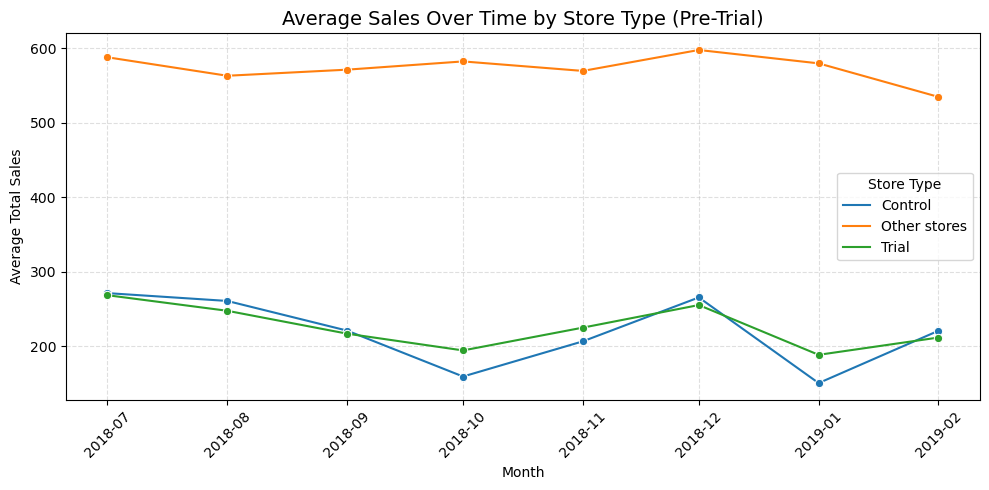

In [73]:
def plot_sales_trends(measure_over_time, trial_store, control_store):
    """
    Visualizes sales trends over time for trial, control, and other stores.
    
    Parameters:
    - measure_over_time (pd.DataFrame): DataFrame with columns 'STORE_NBR', 'YEARMONTH', 'totSales'
    - trial_store (int): Store number of the trial store
    - control_store (int): Store number of the control store
    """
    # Copy and assign Store_type
    measureOverTimeSales = measure_over_time.copy()
    measureOverTimeSales['Store_type'] = measureOverTimeSales['STORE_NBR'].apply(
        lambda x: 'Trial' if x == trial_store else ('Control' if x == control_store else 'Other stores')
    )

    # Group and aggregate average sales
    pastSales = (
        measureOverTimeSales
        .groupby(['YEARMONTH', 'Store_type'], as_index=False)['totSales']
        .mean()
    )

    # Convert YEARMONTH to datetime
    pastSales['TransactionMonth'] = pd.to_datetime(
        pastSales['YEARMONTH'].astype(str), format='%Y%m'
    )

    # Filter pre-trial period (before March 2019)
    pastSales = pastSales[pastSales['YEARMONTH'] < 201903]

    # Plot
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=pastSales, x='TransactionMonth', y='totSales', hue='Store_type', marker='o')
    plt.title('Average Sales Over Time by Store Type (Pre-Trial)', fontsize=14)
    plt.xlabel('Month')
    plt.ylabel('Average Total Sales')
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.legend(title='Store Type')
    plt.show()

    
plot_sales_trends(measure_over_time, trial_store=77, control_store=233)


### Customer Count Over Time

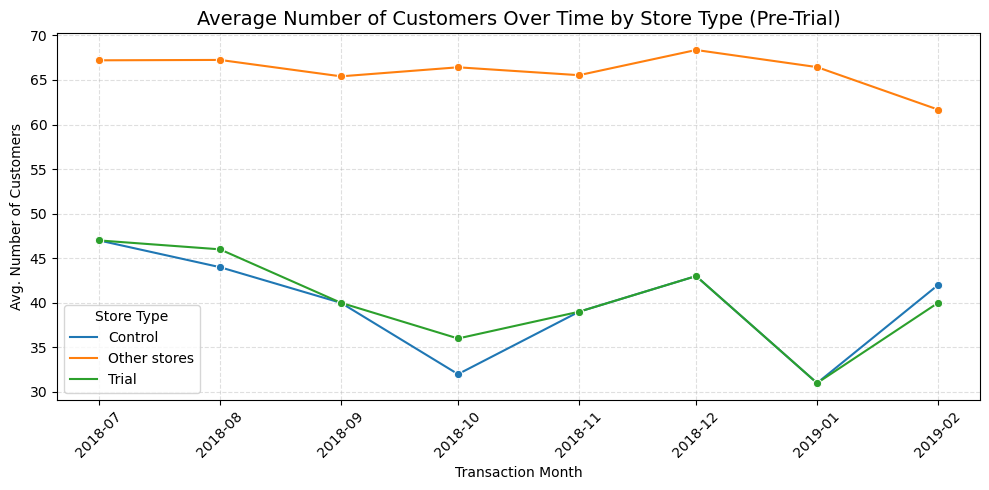

In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_customer_trends(measure_over_time, trial_store, control_store):
    """
    Visualizes number of customers over time for trial, control, and other stores (pre-trial period).
    
    Parameters:
    - measure_over_time (pd.DataFrame): DataFrame with 'STORE_NBR', 'YEARMONTH', 'nCustomers' columns
    - trial_store (int): Store number of the trial store
    - control_store (int): Store number of the control store
    """
    # Copy and assign store type
    measureOverTimeCust = measure_over_time.copy()
    measureOverTimeCust['Store_type'] = measureOverTimeCust['STORE_NBR'].apply(
        lambda x: 'Trial' if x == trial_store else ('Control' if x == control_store else 'Other stores')
    )

    # Group by YEARMONTH and Store_type and calculate mean number of customers
    pastCustomers = (
        measureOverTimeCust
        .groupby(['YEARMONTH', 'Store_type'], as_index=False)['nCustomers']
        .mean()
    )

    # Create datetime column
    pastCustomers['TransactionMonth'] = pd.to_datetime(
        pastCustomers['YEARMONTH'].astype(str), format='%Y%m'
    )

    # Filter pre-trial data
    pastCustomers = pastCustomers[pastCustomers['YEARMONTH'] < 201903]

    # Plot
    plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=pastCustomers,
        x='TransactionMonth',
        y='nCustomers',
        hue='Store_type',
        marker='o'
    )
    plt.title('Average Number of Customers Over Time by Store Type (Pre-Trial)', fontsize=14)
    plt.xlabel('Transaction Month')
    plt.ylabel('Avg. Number of Customers')
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend(title='Store Type')
    plt.tight_layout()
    plt.show()

    
plot_customer_trends(measure_over_time, trial_store=77, control_store=233)


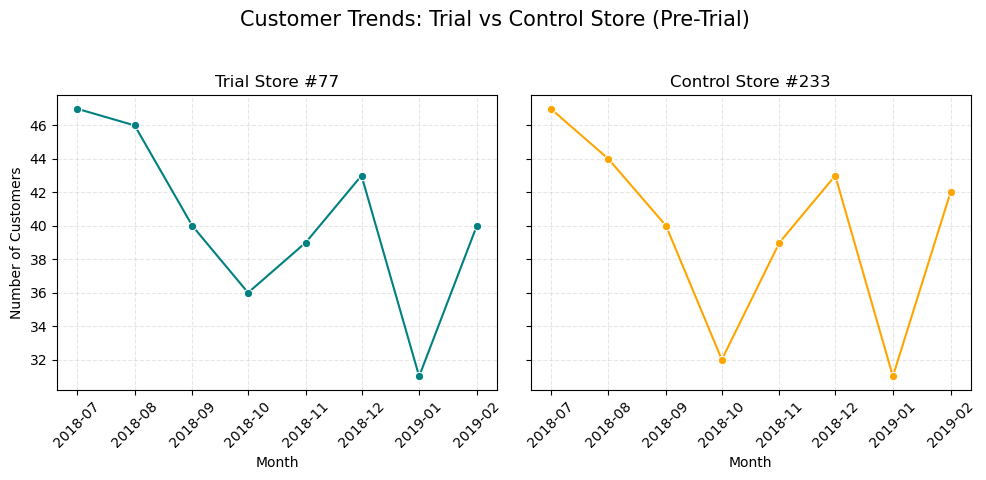

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_trial_vs_control_customers(measure_over_time, trial_store, control_store):
    """
    Plots customer trends over time for trial and control stores in two side-by-side plots.
    
    Parameters:
    - measure_over_time (pd.DataFrame): Must contain 'STORE_NBR', 'YEARMONTH', 'nCustomers'
    - trial_store (int): Trial store number
    - control_store (int): Control store number
    """
    # Filter for trial and control stores
    df = measure_over_time.copy()
    df = df[df['STORE_NBR'].isin([trial_store, control_store])].copy()
    
    # Add TransactionMonth for x-axis
    df['TransactionMonth'] = pd.to_datetime(df['YEARMONTH'].astype(str), format='%Y%m')

    # Filter pre-trial only if needed
    df = df[df['YEARMONTH'] < 201903]

    # Create figure and axes
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    # Plot for Trial Store
    sns.lineplot(
        data=df[df['STORE_NBR'] == trial_store],
        x='TransactionMonth',
        y='nCustomers',
        marker='o',
        ax=axes[0],
        color='teal'
    )
    axes[0].set_title(f'Trial Store #{trial_store}')
    axes[0].set_xlabel('Month')
    axes[0].set_ylabel('Number of Customers')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, linestyle='--', alpha=0.3)

    # Plot for Control Store
    sns.lineplot(
        data=df[df['STORE_NBR'] == control_store],
        x='TransactionMonth',
        y='nCustomers',
        marker='o',
        ax=axes[1],
        color='orange'
    )
    axes[1].set_title(f'Control Store #{control_store}')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, linestyle='--', alpha=0.3)

    # Final layout
    plt.suptitle('Customer Trends: Trial vs Control Store (Pre-Trial)', fontsize=15)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
plot_trial_vs_control_customers(measure_over_time, trial_store=77, control_store=233)


# 7. Trial Assessment

### Scaling Control Sales

The trial ran from February 2019 to April 2019. To assess impact, we normalize the control store's sales to match the trial store in the pre-trial period and calculate the percentage difference.

In [25]:
def scale_control_sales(measure_over_time, pre_trial_data, trial_store, control_store):
    """
    Scales control store sales to match the pre-trial total sales level of the trial store.
    
    Returns a DataFrame with the control store's scaled sales.
    """
    # Step 1: Calculate scaling factor based on pre-trial sales
    scaling_factor = (
        pre_trial_data[(pre_trial_data['STORE_NBR'] == trial_store) & (pre_trial_data['YEARMONTH'] < 201902)]['totSales'].sum()
        /
        pre_trial_data[(pre_trial_data['STORE_NBR'] == control_store) & (pre_trial_data['YEARMONTH'] < 201902)]['totSales'].sum()
    )

    # Step 2: Apply scaling factor to control store's sales
    measureOverTimeSales = measure_over_time.copy()
    scaledControlSales = measureOverTimeSales[measureOverTimeSales['STORE_NBR'] == control_store].copy()
    scaledControlSales['controlSales'] = scaledControlSales['totSales'] * scaling_factor

    return measureOverTimeSales, scaledControlSales, scaling_factor


measureOverTimeSales, scaledControlSales, scaling_factor = scale_control_sales(
    measure_over_time,
    pre_trial_data,
    trial_store,
    control_store
)


In [26]:
scaling_factor

1.0397523623330076

In [27]:
measureOverTimeSales[measureOverTimeSales['STORE_NBR'] == trial_store].reset_index()

,index,STORE_NBR,YEARMONTH,totSales,nCustomers,nTxnPerCust,nChipsPerCust,avgPricePerUnit
0,880,77,201807,268.4,47,51,1.638298,3.485714
1,881,77,201808,247.5,46,46,1.543478,3.485915
2,882,77,201809,216.8,40,42,1.650000,3.284848
3,883,77,201810,194.3,36,37,1.388889,3.886000
4,884,77,201811,224.9,39,42,1.615385,3.569841
5,885,77,201812,255.2,43,44,1.558140,3.808955
6,886,77,201901,188.4,31,35,1.870968,3.248276
7,887,77,201902,211.6,40,40,1.675000,3.158209
8,888,77,201903,255.1,46,51,1.652174,3.356579
9,889,77,201904,258.1,47,47,1.617021,3.396053


In [28]:
measureOverTimeSales[measureOverTimeSales['STORE_NBR'] == control_store].reset_index()

,index,STORE_NBR,YEARMONTH,totSales,nCustomers,nTxnPerCust,nChipsPerCust,avgPricePerUnit
0,2695,233,201807,271.2,47,49,1.680851,3.432911
1,2696,233,201808,260.7,44,45,1.636364,3.620833
2,2697,233,201809,220.9,40,43,1.700000,3.248529
3,2698,233,201810,159.3,32,32,1.500000,3.318750
4,2699,233,201811,206.5,39,40,1.564103,3.385246
5,2700,233,201812,265.4,43,45,1.627907,3.791429
6,2701,233,201901,150.5,31,31,1.322581,3.670732
7,2702,233,201902,220.7,42,43,1.523810,3.448437
8,2703,233,201903,180.6,35,36,1.485714,3.473077
9,2704,233,201904,144.2,27,28,1.518519,3.517073


### Percentage Difference

Percentage differnce is calculated over entire period (pre-trial + trial)

In [29]:
def calculate_percentage_difference(measure_over_time, trial_store, scaledControlSales):
    """
    Calculate the percentage difference between scaled control sales and trial store sales.
    
    Parameters:
    - measure_over_time: original sales DataFrame
    - trial_store: trial store number
    - scaledControlSales: DataFrame of scaled control sales with columns ['YEARMONTH', 'controlSales']
    
    Returns:
    - percentageDiff: DataFrame with ['YEARMONTH', 'controlSales', 'totSales', 'percentageDiff']
    """
    # Step 1: Get trial store sales
    trialSales = measure_over_time[measure_over_time['STORE_NBR'] == trial_store][['YEARMONTH', 'totSales']].copy()

    # Step 2: Merge with scaled control sales on YEARMONTH
    percentageDiff = pd.merge(
        scaledControlSales[['YEARMONTH', 'controlSales']],
        trialSales,
        on='YEARMONTH'
    )

    # Step 3: Calculate percentage difference
    percentageDiff['percentageDiff'] = abs(percentageDiff['controlSales'] - percentageDiff['totSales']) / percentageDiff['controlSales']

    return percentageDiff


percentageDiff = calculate_percentage_difference(measure_over_time, trial_store, scaledControlSales)


In [30]:
percentageDiff

,YEARMONTH,controlSales,totSales,percentageDiff
0,201807,281.980841,268.4,0.048162
1,201808,271.063441,247.5,0.086930
2,201809,229.681297,216.8,0.056083
3,201810,165.632551,194.3,0.173079
4,201811,214.708863,224.9,0.047465
5,201812,275.950277,255.2,0.075196
6,201901,156.482731,188.4,0.203967
7,201902,229.473346,211.6,0.077889
8,201903,187.779277,255.1,0.358510
9,201904,149.932291,258.1,0.721444


### Statistical Significance (t-test)

In [31]:
trial_store = 77
control_store = 233

In [32]:
import pandas as pd
from scipy.stats import t

def calculate_t_values(measure_over_time, trial_store, control_store):
    """
    Calculate t-values for percentage differences between trial and control store sales.
    
    Parameters:
    - measure_over_time: original sales DataFrame
    - trial_store: trial store number
    - control_store: control store number
    
    Returns:
    - merged_sales: DataFrame with percentageDiff, tValue, and TransactionMonth
    - stdDev_sales: standard deviation of percentageDiff in pre-trial period
    - degreesOfFreedom: degrees of freedom (hardcoded as 7)
    - t_critical: 95th percentile critical t-value
    - trial_tvals: filtered t-values for the trial period
    """
    # Calculate total sales per store per month
    sales_df = measure_over_time[['STORE_NBR', 'YEARMONTH', 'totSales']].copy()

    # Trial and control data
    trial_sales = sales_df[sales_df['STORE_NBR'] == trial_store]
    control_sales = sales_df[sales_df['STORE_NBR'] == control_store]

    # Merge on YEARMONTH and calculate percentage difference
    merged_sales = pd.merge(trial_sales, control_sales, on='YEARMONTH', suffixes=('_trial', '_control'))
    merged_sales['percentageDiff'] = abs(merged_sales['totSales_trial'] - merged_sales['totSales_control']) / merged_sales['totSales_control']

    # Standard deviation in pre-trial months (before Feb 2019)
    pre_trial_sales = merged_sales[merged_sales['YEARMONTH'] < 201902]
    stdDev_sales = pre_trial_sales['percentageDiff'].std()
    degreesOfFreedom = 7

    # t = (observed_diff - 0) / stdDev
    merged_sales['tValue'] = merged_sales['percentageDiff'] / stdDev_sales

    # Create TransactionMonth for plotting
    merged_sales['TransactionMonth'] = pd.to_datetime(merged_sales['YEARMONTH'].astype(str) + '01', format='%Y%m%d')

    # Filter for trial period (Feb 2019 to Apr 2019)
    trial_tvals = merged_sales[(merged_sales['YEARMONTH'] > 201901) & (merged_sales['YEARMONTH'] < 201905)][['TransactionMonth', 'tValue']]

    # Critical t-value at 95% confidence level
    t_critical = t.ppf(0.95, df=degreesOfFreedom)

    return merged_sales, stdDev_sales, degreesOfFreedom, t_critical, trial_tvals


merged_sales, stdDev_sales, degreesOfFreedom, t_critical, trial_tvals = calculate_t_values(measure_over_time, trial_store, control_store)
print(trial_tvals)
print("95th percentile t-value:", t_critical)


  TransactionMonth    tValue
7       2019-02-01  0.418159
8       2019-03-01  4.183511
9       2019-04-01  8.010524
95th percentile t-value: 1.894578605061305


### Visualizing Confidence Intervals (SALES)

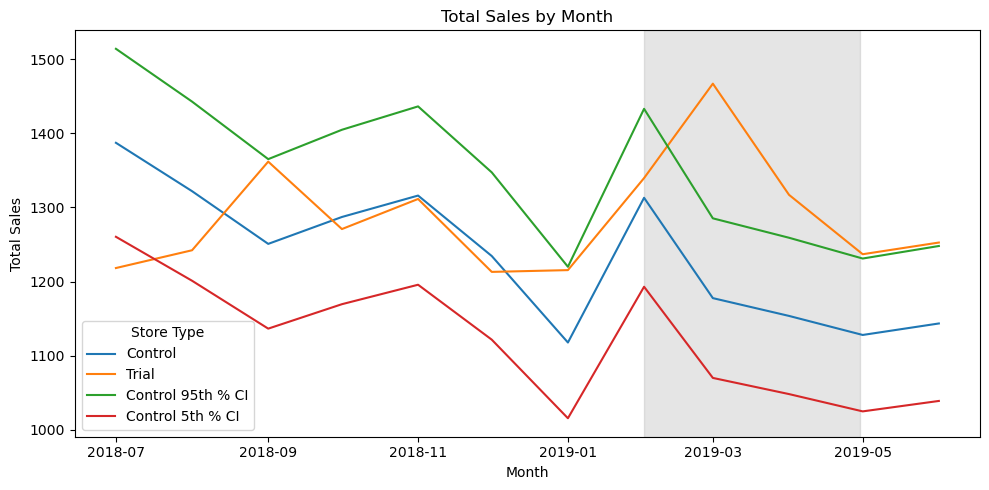

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np
import pandas as pd

def plot_sales_over_time(measure_over_time, trial_store, control_store, stdDev_sales):
    """
    Plot total sales over time for trial and control stores with control store's 95% confidence interval.
    
    Parameters:
    - measure_over_time: DataFrame containing sales data with columns ['STORE_NBR', 'YEARMONTH', 'totSales']
    - trial_store: store number of the trial store
    - control_store: store number of the control store
    - stdDev_sales: standard deviation used for confidence interval scaling
    
    Returns:
    - sales_plot_df: DataFrame used for plotting
    """
    # Assign Store_type
    measure_over_time['Store_type'] = np.where(
        measure_over_time['STORE_NBR'] == trial_store, 'Trial',
        np.where(measure_over_time['STORE_NBR'] == control_store, 'Control', 'Other stores')
    )
    
    # Aggregate mean sales by YEARMONTH and Store_type
    sales_summary = measure_over_time.groupby(['YEARMONTH', 'Store_type'])['totSales'].mean().reset_index()
    sales_summary['TransactionMonth'] = pd.to_datetime(sales_summary['YEARMONTH'].astype(str) + '01', format='%Y%m%d')
    
    # Calculate control bounds for approx 95% CI (±2 std)
    control_bounds = sales_summary[sales_summary['Store_type'] == 'Control'].copy()
    
    control_bounds_upper = control_bounds.copy()
    control_bounds_upper['totSales'] *= (1 + 2 * stdDev_sales)
    control_bounds_upper['Store_type'] = 'Control 95th % CI'
    
    control_bounds_lower = control_bounds.copy()
    control_bounds_lower['totSales'] *= (1 - 2 * stdDev_sales)
    control_bounds_lower['Store_type'] = 'Control 5th % CI'
    
    # Combine for plotting
    sales_plot_df = pd.concat([
        sales_summary[sales_summary['Store_type'].isin(['Trial', 'Control'])],
        control_bounds_upper,
        control_bounds_lower
    ])
    
    # Plot
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=sales_plot_df, x='TransactionMonth', y='totSales', hue='Store_type')
    plt.axvspan(datetime(2019, 2, 1), datetime(2019, 4, 30), color='grey', alpha=0.2)
    plt.title("Total Sales by Month")
    plt.xlabel("Month")
    plt.ylabel("Total Sales")
    plt.legend(title="Store Type")
    plt.tight_layout()
    plt.show()
    
    return sales_plot_df


sales_plot_df = plot_sales_over_time(measure_over_time, trial_store, control_store, stdDev_sales)

### Customer Count Impact

#### Scaling and Differences

#### Visual Confidence Bands for Customers

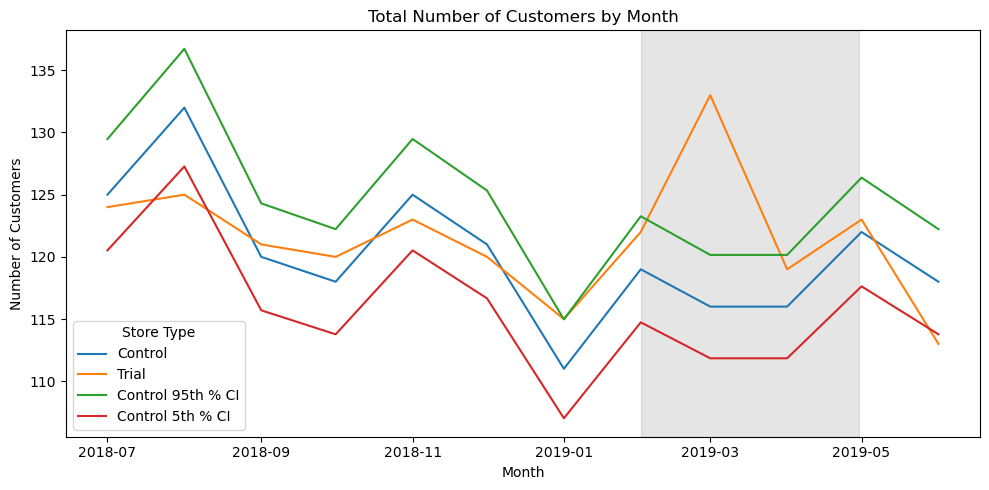

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

def plot_customers_over_time(measure_over_time, trial_store, control_store):
    """
    Scale control store customers to match pre-trial trial store customers,
    calculate percentage differences and std deviation,
    and plot total number of customers over time with confidence intervals.
    
    Parameters:
    - measure_over_time: DataFrame with columns including ['STORE_NBR', 'YEARMONTH', 'nCustomers']
    - trial_store: int or str, store number for the trial store
    - control_store: int or str, store number for the control store
    
    Returns:
    - cust_plot_df: DataFrame used for plotting
    - stdDev_cust: standard deviation of percentageDiff in pre-trial period
    """
    
    # Scale control customers to match pre-trial trial customers
    pre_trial_custs = measure_over_time[measure_over_time['YEARMONTH'] < 201902]
    trial_sum = pre_trial_custs[pre_trial_custs['STORE_NBR'] == trial_store]['nCustomers'].sum()
    control_sum = pre_trial_custs[pre_trial_custs['STORE_NBR'] == control_store]['nCustomers'].sum()
    scalingFactor = trial_sum / control_sum

    # Apply scaling
    cust_df = measure_over_time.copy()
    cust_df['controlCustomers'] = np.where(
        cust_df['STORE_NBR'] == control_store,
        cust_df['nCustomers'] * scalingFactor,
        np.nan
    )

    # Merge trial + scaled control
    trial_cust = cust_df[cust_df['STORE_NBR'] == trial_store][['YEARMONTH', 'nCustomers']]
    control_cust = cust_df[cust_df['STORE_NBR'] == control_store][['YEARMONTH', 'controlCustomers']]
    merged_cust = pd.merge(trial_cust, control_cust, on='YEARMONTH')
    merged_cust['percentageDiff'] = abs(merged_cust['controlCustomers'] - merged_cust['nCustomers']) / merged_cust['controlCustomers']

    # Standard deviation in pre-trial
    stdDev_cust = merged_cust[merged_cust['YEARMONTH'] < 201902]['percentageDiff'].std()

    # Aggregate mean customers
    cust_df['Store_type'] = np.where(
        cust_df['STORE_NBR'] == trial_store, 'Trial',
        np.where(cust_df['STORE_NBR'] == control_store, 'Control', 'Other stores')
    )

    cust_summary = cust_df.groupby(['YEARMONTH', 'Store_type'])['nCustomers'].mean().reset_index()
    cust_summary['TransactionMonth'] = pd.to_datetime(cust_summary['YEARMONTH'].astype(str) + '01', format='%Y%m%d')

    # CI bounds for control
    control_cust_bounds = cust_summary[cust_summary['Store_type'] == 'Control'].copy()
    upper = control_cust_bounds.copy()
    lower = control_cust_bounds.copy()

    upper['nCustomers'] *= (1 + 2 * stdDev_cust)
    upper['Store_type'] = 'Control 95th % CI'
    lower['nCustomers'] *= (1 - 2 * stdDev_cust)
    lower['Store_type'] = 'Control 5th % CI'

    cust_plot_df = pd.concat([
        cust_summary[cust_summary['Store_type'].isin(['Trial', 'Control'])],
        upper,
        lower
    ])

    # Plot
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=cust_plot_df, x='TransactionMonth', y='nCustomers', hue='Store_type')
    plt.axvspan(datetime(2019, 2, 1), datetime(2019, 4, 30), color='grey', alpha=0.2)
    plt.title("Total Number of Customers by Month")
    plt.xlabel("Month")
    plt.ylabel("Number of Customers")
    plt.legend(title="Store Type")
    plt.tight_layout()
    plt.show()

    return cust_plot_df, stdDev_cust


cust_plot_df, stdDev_cust = plot_customers_over_time(measure_over_time, trial_store, control_store)


# Trial Store Analysis

# Trial Store = 77

In [35]:
trial_store = 77

# Evaluate similarity scores
store_similarity = evaluate_store_similarity(pre_trial_data, trial_store)
# print(store_similarity)


# Merge scores and compute final similarity ranking
combined = merge_similarity_scores(
    corr_sales=store_similarity['correlation']['sales'],
    mag_sales=store_similarity['magnitude']['sales'],
    corr_customers=store_similarity['correlation']['customers'],
    mag_customers=store_similarity['magnitude']['customers']
)

best_match = combined.sort_values(by='final_score', ascending=False).iloc[0]
print("best_match:\n",best_match)


best_match:
 Store1              77.000000
Store2             233.000000
corr_measure_x       0.973643
mag_measure_x        0.987092
score_sales          0.980368
corr_measure_y       0.965682
mag_measure_y        0.990963
score_customers      0.978323
final_score          0.979345
Name: 219, dtype: float64


In [36]:
control_store= int(best_match['Store2'])
print("control_store: ", control_store)


control_store:  233


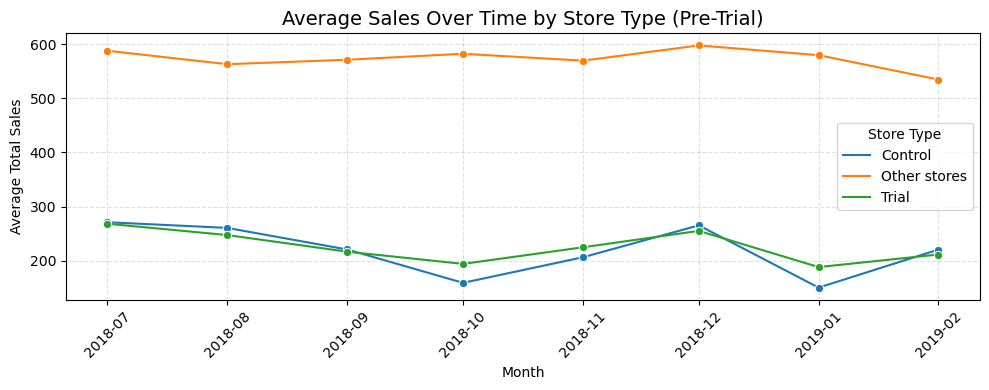

In [70]:
plot_sales_trends(measure_over_time, trial_store=77, control_store=233)

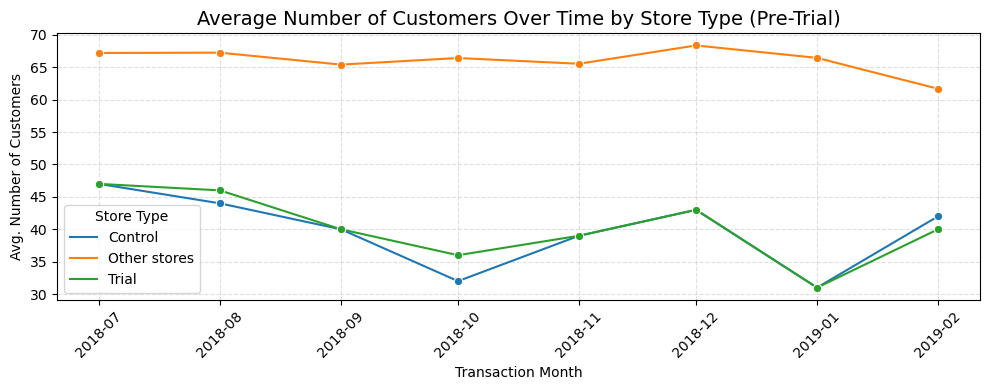

In [38]:
plot_customer_trends(measure_over_time, trial_store=77, control_store=233)


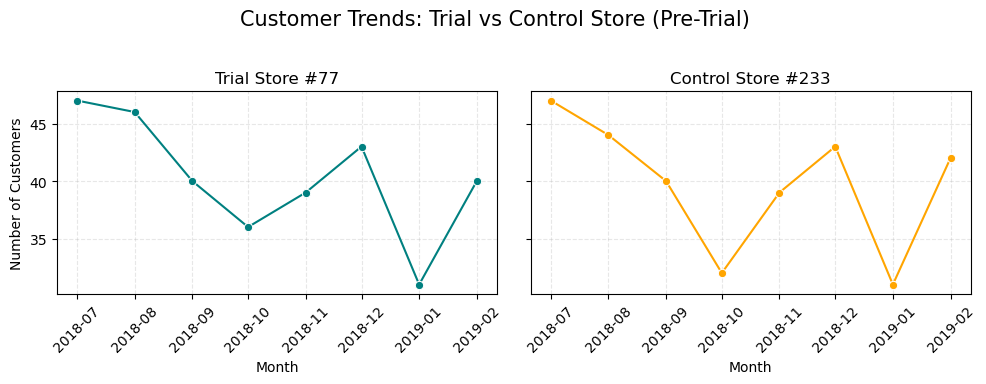

In [39]:
plot_trial_vs_control_customers(measure_over_time, trial_store=77, control_store=233)


In [40]:
measureOverTimeSales, scaledControlSales, scaling_factor = scale_control_sales(
    measure_over_time,
    pre_trial_data,
    trial_store,
    control_store
)


print("scaling_factor : ", scaling_factor)

scaling_factor :  1.0397523623330076


In [41]:
percentageDiff = calculate_percentage_difference(measure_over_time, trial_store, scaledControlSales)
print("percentageDiff:\n\n")

percentageDiff

percentageDiff:




,YEARMONTH,controlSales,totSales,percentageDiff
0,201807,281.980841,268.4,0.048162
1,201808,271.063441,247.5,0.086930
2,201809,229.681297,216.8,0.056083
3,201810,165.632551,194.3,0.173079
4,201811,214.708863,224.9,0.047465
5,201812,275.950277,255.2,0.075196
6,201901,156.482731,188.4,0.203967
7,201902,229.473346,211.6,0.077889
8,201903,187.779277,255.1,0.358510
9,201904,149.932291,258.1,0.721444


In [42]:
merged_sales, stdDev_sales, degreesOfFreedom, t_critical, trial_tvals = calculate_t_values(measure_over_time, trial_store, control_store)
print(trial_tvals)
print("\n\n")
print("95th percentile t-value:", t_critical)

  TransactionMonth    tValue
7       2019-02-01  0.418159
8       2019-03-01  4.183511
9       2019-04-01  8.010524



95th percentile t-value: 1.894578605061305


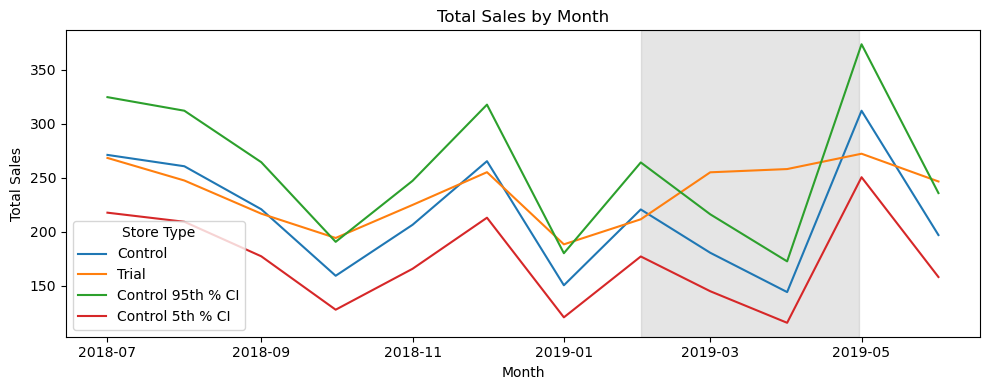

In [43]:
sales_plot_df = plot_sales_over_time(measure_over_time, trial_store, control_store, stdDev_sales)

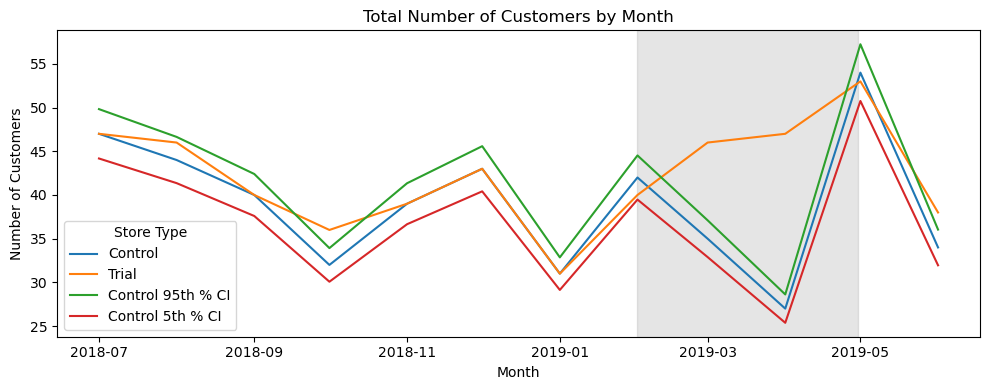

In [44]:
cust_plot_df, stdDev_cust = plot_customers_over_time(measure_over_time, trial_store, control_store)

# Trial Store = 86

In [45]:
trial_store = 86

# Evaluate similarity scores
store_similarity = evaluate_store_similarity(pre_trial_data, trial_store)
# print(store_similarity)


# Merge scores and compute final similarity ranking
combined = merge_similarity_scores(
    corr_sales=store_similarity['correlation']['sales'],
    mag_sales=store_similarity['magnitude']['sales'],
    corr_customers=store_similarity['correlation']['customers'],
    mag_customers=store_similarity['magnitude']['customers']
)

best_match = combined.sort_values(by='final_score', ascending=False).iloc[0]
print("best_match:\n",best_match)


best_match:
 Store1              86.000000
Store2             155.000000
corr_measure_x       0.869532
mag_measure_x        0.963368
score_sales          0.916450
corr_measure_y       0.829086
mag_measure_y        0.972108
score_customers      0.900597
final_score          0.908524
Name: 146, dtype: float64


In [46]:
control_store= int(best_match['Store2'])
print("control_store: ", control_store)


control_store:  155


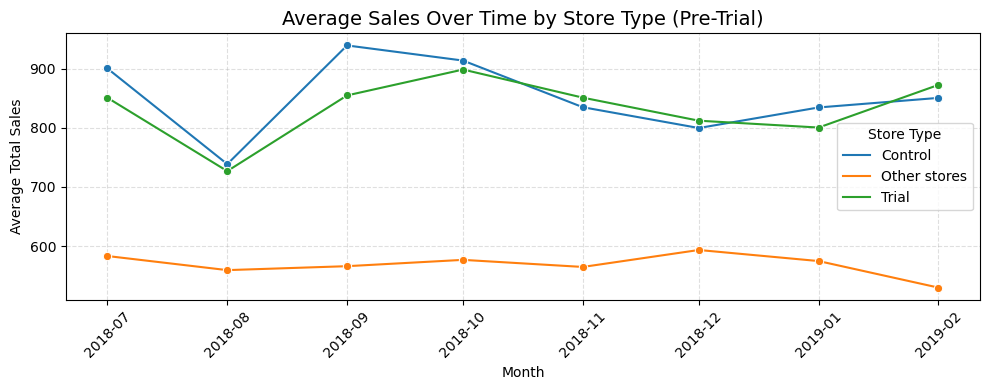

In [47]:
plot_sales_trends(measure_over_time, trial_store, control_store)

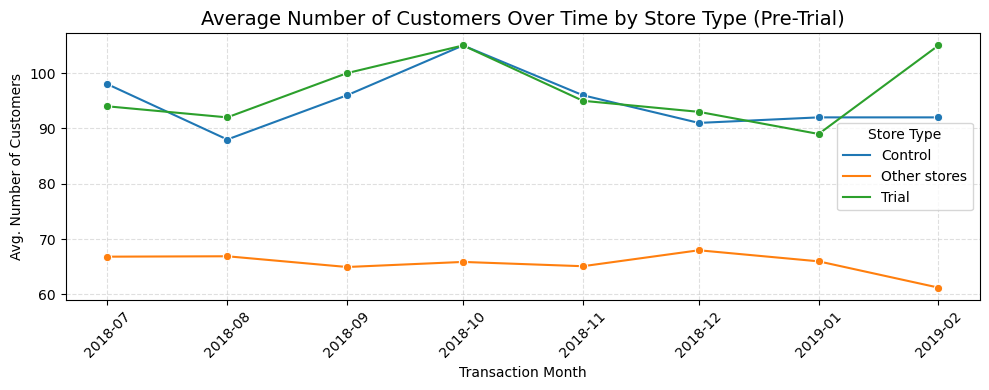

In [48]:
plot_customer_trends(measure_over_time, trial_store, control_store)

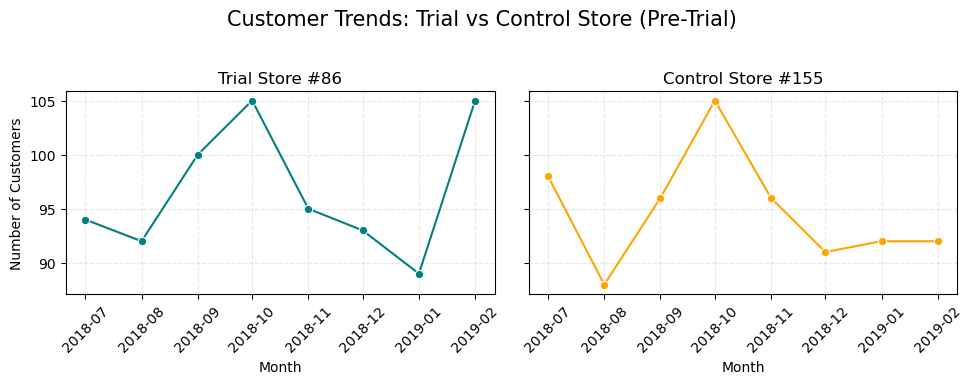

In [49]:
plot_trial_vs_control_customers(measure_over_time, trial_store, control_store)

In [50]:
measureOverTimeSales, scaledControlSales, scaling_factor = scale_control_sales(
    measure_over_time,
    pre_trial_data,
    trial_store,
    control_store
)


print("scaling_factor : ", scaling_factor)

scaling_factor :  0.9720493769183033


In [51]:
percentageDiff = calculate_percentage_difference(measure_over_time, trial_store, scaledControlSales)
print("percentageDiff:")

percentageDiff

percentageDiff:


,YEARMONTH,controlSales,totSales,percentageDiff
0,201807,875.427669,851.00,0.027904
1,201808,718.052875,726.85,0.012251
2,201809,913.337595,855.00,0.063873
3,201810,888.453131,898.80,0.011646
4,201811,811.661230,851.20,0.048713
5,201812,777.445092,812.20,0.044704
6,201901,811.272410,800.60,0.013155
7,201902,827.019610,872.80,0.055356
8,201903,745.561872,945.40,0.268037
9,201904,778.028321,804.00,0.033381


In [52]:
merged_sales, stdDev_sales, degreesOfFreedom, t_critical, trial_tvals = calculate_t_values(measure_over_time, trial_store, control_store)
print(trial_tvals)
print("\n\n")
print("95th percentile t-value:", t_critical)

  TransactionMonth    tValue
7       2019-02-01  0.916584
8       2019-03-01  8.244729
9       2019-04-01  0.159431



95th percentile t-value: 1.894578605061305


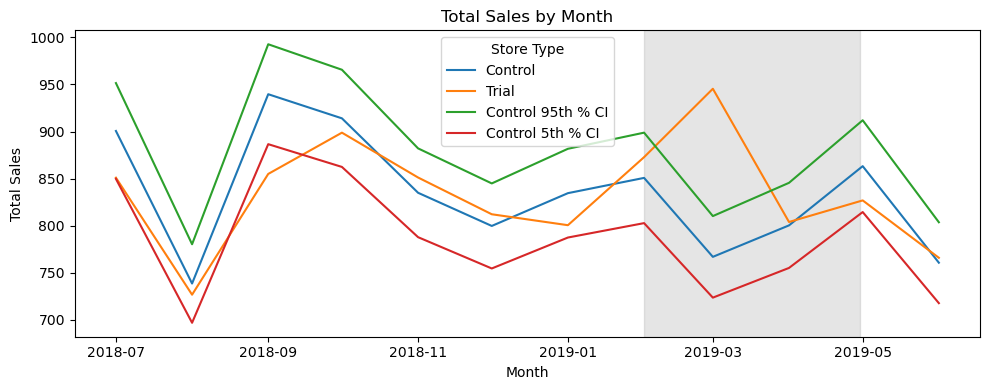

In [53]:
sales_plot_df = plot_sales_over_time(measure_over_time, trial_store, control_store, stdDev_sales)


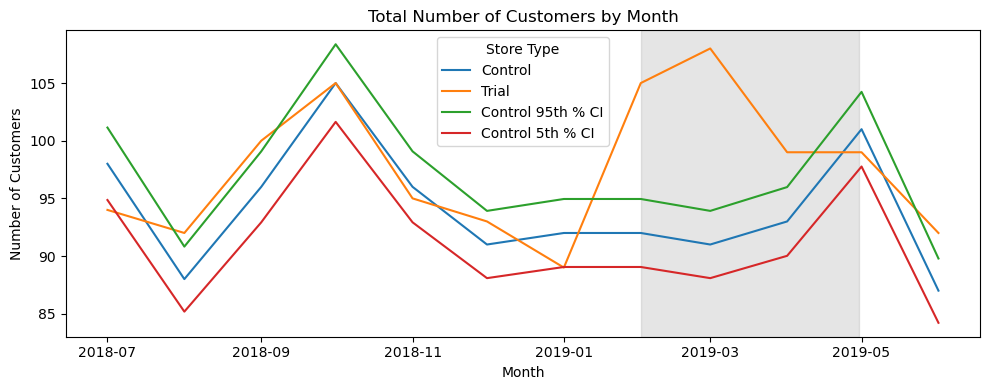

In [54]:
cust_plot_df, stdDev_cust = plot_customers_over_time(measure_over_time, trial_store, control_store)


# Trial Store = 88 

In [55]:
trial_store = 88

# Evaluate similarity scores
store_similarity = evaluate_store_similarity(pre_trial_data, trial_store)
# print(store_similarity)


# Merge scores and compute final similarity ranking
combined = merge_similarity_scores(
    corr_sales=store_similarity['correlation']['sales'],
    mag_sales=store_similarity['magnitude']['sales'],
    corr_customers=store_similarity['correlation']['customers'],
    mag_customers=store_similarity['magnitude']['customers']
)

# print("combined",combined)

best_match = combined.sort_values(by='final_score', ascending=False).iloc[0]
print("best_match:\n", best_match)

best_match:
 Store1              88.000000
Store2             237.000000
corr_measure_x       0.109878
mag_measure_x        0.949025
score_sales          0.529452
corr_measure_y       0.958896
mag_measure_y        0.981943
score_customers      0.970420
final_score          0.749936
Name: 223, dtype: float64


In [56]:
candidates = combined[combined['Store2'] != trial_store]                # drop yourself
best_match = candidates.sort_values('final_score', ascending=False).iloc[0]
control_store = int(best_match['Store2'])


In [57]:
control_store= int(best_match['Store2'])
# control_store=237
print("control_store: ", control_store)

control_store:  237


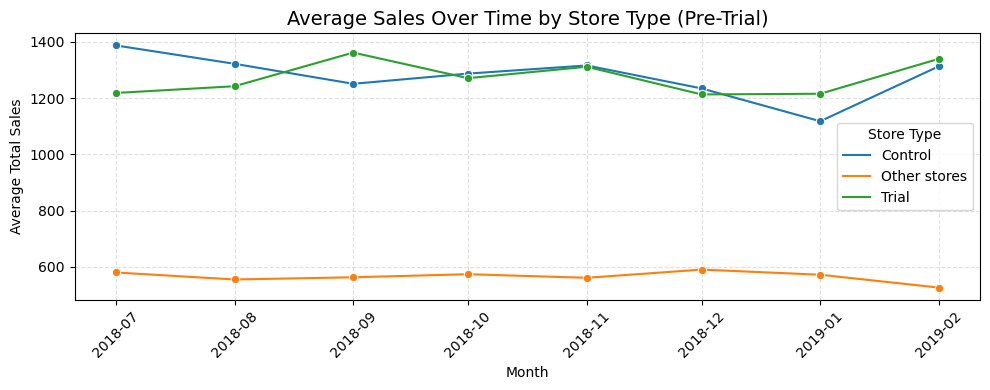

In [58]:
plot_sales_trends(measure_over_time, trial_store, control_store)

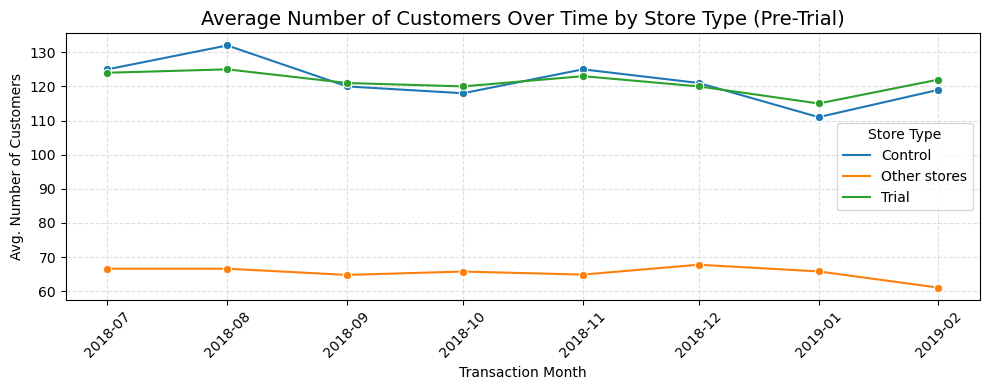

In [59]:
plot_customer_trends(measure_over_time, trial_store, control_store)

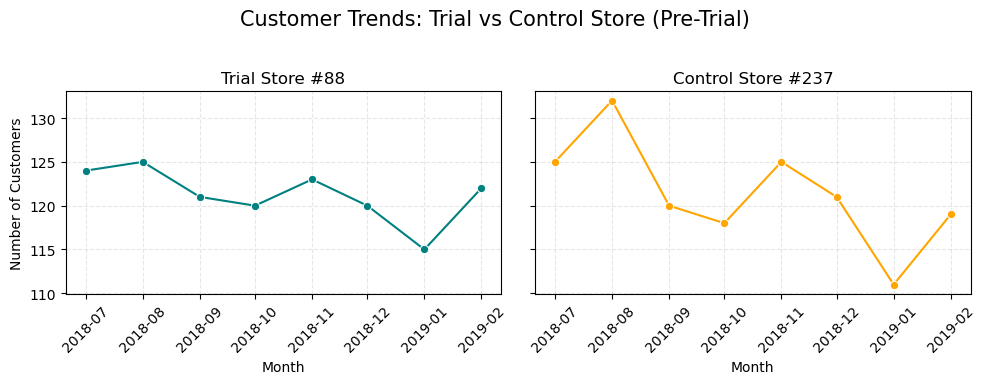

In [60]:
plot_trial_vs_control_customers(measure_over_time, trial_store, control_store)


In [61]:
measureOverTimeSales, scaledControlSales, scaling_factor = scale_control_sales(
    measure_over_time,
    pre_trial_data,
    trial_store,
    control_store
)

print("scaling_factor : ", scaling_factor)

scaling_factor :  0.9907684714697534


In [62]:
percentageDiff = calculate_percentage_difference(measure_over_time, trial_store, scaledControlSales)
print("percentageDiff")

percentageDiff

percentageDiff


,YEARMONTH,controlSales,totSales,percentageDiff
0,201807,1374.394024,1218.20,0.113646
1,201808,1309.696842,1242.20,0.051536
2,201809,1239.253204,1361.80,0.098888
3,201810,1275.218100,1270.80,0.003465
4,201811,1303.851308,1311.40,0.005790
5,201812,1223.004601,1213.00,0.008180
6,201901,1107.381921,1215.40,0.097544
7,201902,1300.879003,1339.60,0.029765
8,201903,1166.728952,1467.00,0.257361
9,201904,1142.950509,1317.00,0.152281


In [63]:
merged_sales, stdDev_sales, degreesOfFreedom, t_critical, trial_tvals = calculate_t_values(measure_over_time, trial_store, control_store)
print(trial_tvals)
print("\n\n")
print("95th percentile t-value:", t_critical)

  TransactionMonth    tValue
7       2019-02-01  0.443140
8       2019-03-01  5.375571
9       2019-04-01  3.098280



95th percentile t-value: 1.894578605061305


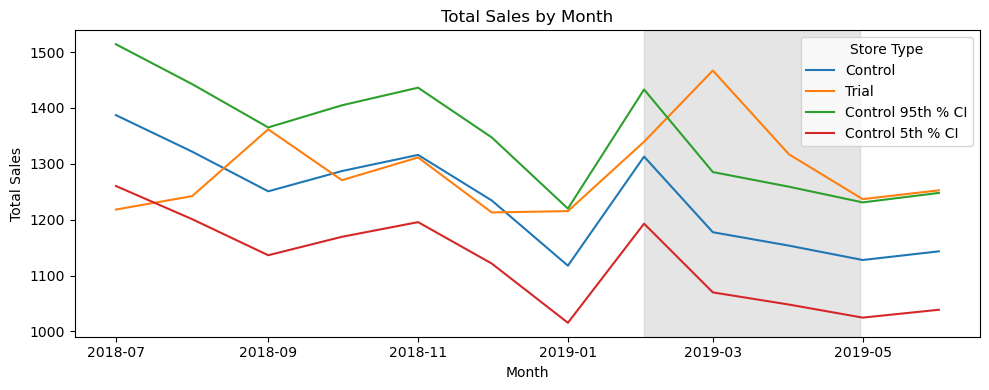

In [64]:
sales_plot_df = plot_sales_over_time(measure_over_time, trial_store, control_store, stdDev_sales)


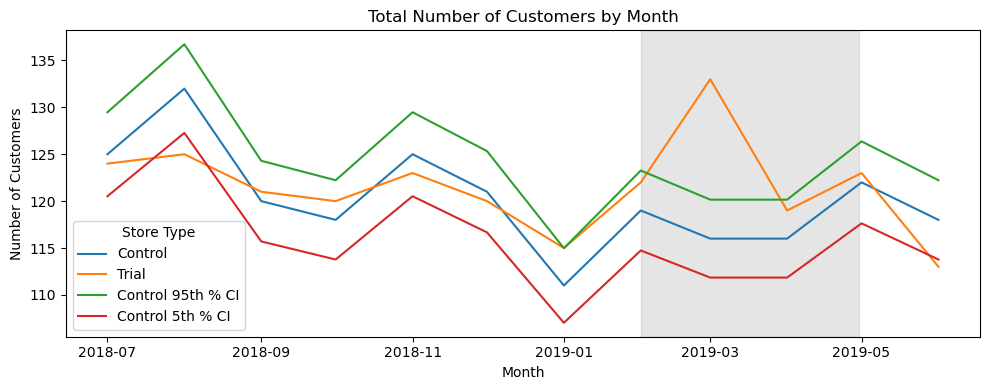

In [65]:
cust_plot_df, stdDev_cust = plot_customers_over_time(measure_over_time, trial_store, control_store)
